---
# 🟢 PARTIE III — RNN / LSTM / GRU / Transformers  <a id='partie-iii'></a>

**Thème :** Modélisation de séquences et traduction automatique.

**Dataset réel :** Tatoeba fra-eng — paires de phrases français–anglais.



---
##  Étape III.1 — Comparaison RNN / LSTM / GRU

In [2]:
# ================================================================
# IMPORTS
# ================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time
import unicodedata
import re
import random
import math
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

Device : cpu


In [3]:
# ================================================================
# COMPARAISON RNN / LSTM / GRU
# Paramètres, temps forward, stabilité des gradients
# ================================================================
batch_size  = 8
seq_len     = 20
input_size  = 16
hidden_size = 32
X_seq = torch.randn(batch_size, seq_len, input_size).to(device)

rnn  = nn.RNN( input_size=input_size, hidden_size=hidden_size, batch_first=True).to(device)
lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True).to(device)
gru  = nn.GRU( input_size=input_size, hidden_size=hidden_size, batch_first=True).to(device)

# Mesure temps forward
n_runs = 100
resultats_comp = {}
for nom, modele in [('RNN', rnn), ('LSTM', lstm), ('GRU', gru)]:
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            if nom == 'LSTM':
                h0 = torch.zeros(1, batch_size, hidden_size).to(device)
                c0 = torch.zeros(1, batch_size, hidden_size).to(device)
                modele(X_seq, (h0, c0))
            else:
                h0 = torch.zeros(1, batch_size, hidden_size).to(device)
                modele(X_seq, h0)
    temps = (time.time() - start) / n_runs * 1000
    resultats_comp[nom] = {
        'params'  : sum(p.numel() for p in modele.parameters()),
        'temps_ms': round(temps, 3),
        'portes'  : '3 portes' if nom=='LSTM' else ('2 portes' if nom=='GRU' else 'Aucune')
    }

print('=== Comparaison RNN / LSTM / GRU ===')
print(f'{"Modèle":<8} {"Paramètres":<14} {"Temps (ms)":<14} {"Portes"}')
print('-' * 55)
for nom, res in resultats_comp.items():
    print(f'{nom:<8} {res["params"]:<14} {res["temps_ms"]:<14} {res["portes"]}')

=== Comparaison RNN / LSTM / GRU ===
Modèle   Paramètres     Temps (ms)     Portes
-------------------------------------------------------
RNN      1600           1.283          Aucune
LSTM     6400           1.217          3 portes
GRU      4800           1.648          2 portes


RNN    — norme moy gradients : 0.536053
LSTM   — norme moy gradients : 0.138564
GRU    — norme moy gradients : 0.255656


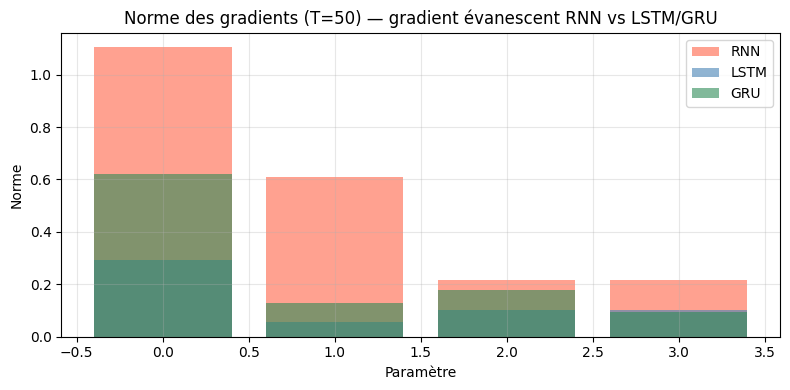

In [4]:
# ================================================================
# STABILITÉ DES GRADIENTS — séquence longue T=50
# ================================================================
X_long  = torch.randn(4, 50, input_size).to(device)
y_dummy = torch.randint(0, 10, (4,)).to(device)
norms_gradients = {}

for nom, arch_class in [('RNN', nn.RNN), ('LSTM', nn.LSTM), ('GRU', nn.GRU)]:
    modele = arch_class(input_size, hidden_size, batch_first=True).to(device)
    fc     = nn.Linear(hidden_size, 10).to(device)
    out, _ = modele(X_long)
    loss   = nn.CrossEntropyLoss()(fc(out[:,-1,:]), y_dummy)
    loss.backward()
    norms  = [p.grad.norm().item() for p in modele.parameters() if p.grad is not None]
    norms_gradients[nom] = norms
    print(f'{nom:<6} — norme moy gradients : {np.mean(norms):.6f}')

couleurs = {'RNN': 'tomato', 'LSTM': 'steelblue', 'GRU': 'seagreen'}
fig, ax = plt.subplots(figsize=(8, 4))
for nom, norms in norms_gradients.items():
    ax.bar(range(len(norms)), norms, alpha=0.6, label=nom, color=couleurs[nom])
ax.set_title('Norme des gradients (T=50) — gradient évanescent RNN vs LSTM/GRU')
ax.set_xlabel('Paramètre'); ax.set_ylabel('Norme')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
##  Étape III.2 — Préparation des données Tatoeba fra-eng

In [5]:
# ================================================================
# TÉLÉCHARGEMENT TATOEBA FRA-ENG — version corrigée
# ================================================================
import urllib.request
import zipfile
import os

url      = 'https://www.manythings.org/anki/fra-eng.zip'
txt_path = 'fra.txt'

if not os.path.exists(txt_path):
    print('Téléchargement Tatoeba fra-eng...')
    # Ajouter un User-Agent pour simuler un navigateur
    req = urllib.request.Request(
        url,
        headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    )
    with urllib.request.urlopen(req) as response:
        with open('fra-eng.zip', 'wb') as f:
            f.write(response.read())
    with zipfile.ZipFile('fra-eng.zip', 'r') as z:
        z.extractall('.')
    print('✅ Dataset téléchargé.')
else:
    print('✅ Dataset déjà présent.')

✅ Dataset déjà présent.


In [6]:
# ================================================================
# NETTOYAGE ET CHARGEMENT DES PAIRES
# ================================================================

import unicodedata  
import re           
import random  

def normaliser(s):
    s = s.lower().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s)
                if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^a-zA-Z.!?]+', ' ', s)
    return s.strip()

def lire_paires(filepath, max_len=10, n_max=5000):
    paires = []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue
            eng = normaliser(parts[0])
            fra = normaliser(parts[1])
            if len(eng.split()) <= max_len and len(fra.split()) <= max_len:
                paires.append((eng, fra))
            if len(paires) >= n_max:
                break
    return paires

paires = lire_paires(txt_path, max_len=10, n_max=5000)
random.shuffle(paires)
print(f'Paires chargées : {len(paires)}')
print('Exemples :')
for eng, fra in paires[:3]:
    print(f'  ENG: {eng}  |  FRA: {fra}')

Paires chargées : 5000
Exemples :
  ENG: keep that.  |  FRA: garde ca.
  ENG: dig faster.  |  FRA: creusez plus vite.
  ENG: come on tom.  |  FRA: allez tom !


In [7]:
# ================================================================
# VOCABULAIRE + TOKENS SPÉCIAUX + ENCODAGE
# ================================================================

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

PAD_IDX = 0; BOS_IDX = 1; EOS_IDX = 2; UNK_IDX = 3
TOKENS_SPECIAUX = ['<pad>', '<bos>', '<eos>', '<unk>']

class Vocabulaire:
    def __init__(self):
        self.mot2idx = {t: i for i, t in enumerate(TOKENS_SPECIAUX)}
        self.idx2mot = {i: t for t, i in self.mot2idx.items()}

    def ajouter_phrase(self, phrase):
        for mot in phrase.split():
            if mot not in self.mot2idx:
                idx = len(self.mot2idx)
                self.mot2idx[mot] = idx
                self.idx2mot[idx] = mot

    def encoder(self, phrase, max_len):
        tokens = [BOS_IDX] + [self.mot2idx.get(m, UNK_IDX) for m in phrase.split()] + [EOS_IDX]
        tokens += [PAD_IDX] * (max_len - len(tokens))
        return tokens[:max_len]

    def decoder(self, indices):
        mots = []
        for i in indices:
            if i == EOS_IDX: break
            if i not in (PAD_IDX, BOS_IDX):
                mots.append(self.idx2mot.get(i, '<unk>'))
        return ' '.join(mots)

    def __len__(self): return len(self.mot2idx)


vocab_src = Vocabulaire()
vocab_tgt = Vocabulaire()
for eng, fra in paires:
    vocab_src.ajouter_phrase(eng)
    vocab_tgt.ajouter_phrase(fra)

MAX_LEN = 14
print(f'Vocab source (ENG) : {len(vocab_src)} mots')
print(f'Vocab cible  (FRA) : {len(vocab_tgt)} mots')

# Encodage + split
X_enc = [vocab_src.encoder(eng, MAX_LEN) for eng, fra in paires]
y_enc = [vocab_tgt.encoder(fra, MAX_LEN) for eng, fra in paires]
X_t   = torch.tensor(X_enc, dtype=torch.long)
y_t   = torch.tensor(y_enc, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.15, random_state=42)
X_train, X_val,  y_train, y_val  = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=64, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=64, shuffle=False)
print(f'Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}')

Vocab source (ENG) : 1441 mots
Vocab cible  (FRA) : 2623 mots
Train : 3612 | Val : 638 | Test : 750


---
##  Étape III.3 — Modèle de langage LSTM

In [8]:
# ================================================================
# LSTM LANGUAGE MODEL
# ================================================================
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb    = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out)


model_lm = LSTMLanguageModel(len(vocab_tgt), embed_size=64, hidden_size=128).to(device)
print(model_lm)
print(f'Paramètres : {sum(p.numel() for p in model_lm.parameters()):,}')

LSTMLanguageModel(
  (embedding): Embedding(2623, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2623, bias=True)
)
Paramètres : 605,567


---
##  Étape III.4 — Entraînement avec gradient clipping (BPTT)

In [9]:
# ================================================================
# LSTM LANGUAGE MODEL
# ================================================================
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.lstm      = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb    = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out)


model_lm = LSTMLanguageModel(len(vocab_tgt), embed_size=64, hidden_size=128).to(device)
print(model_lm)
print(f'Paramètres : {sum(p.numel() for p in model_lm.parameters()):,}')

LSTMLanguageModel(
  (embedding): Embedding(2623, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=2623, bias=True)
)
Paramètres : 605,567


---
##  Étape III.5 — Seq2Seq encodeur–décodeur

Encodeur : 166,720 params
Décodeur : 580,735 params
Epoch  1 | Loss=5.8714
Epoch  2 | Loss=4.4955
Epoch  3 | Loss=4.2184
Epoch  4 | Loss=3.9790
Epoch  5 | Loss=3.7725
Epoch  6 | Loss=3.5742
Epoch  7 | Loss=3.4110
Epoch  8 | Loss=3.2739
Epoch  9 | Loss=3.1371
Epoch 10 | Loss=3.0156
Epoch 11 | Loss=2.9102
Epoch 12 | Loss=2.7853
Epoch 13 | Loss=2.7321
Epoch 14 | Loss=2.6443
Epoch 15 | Loss=2.5692


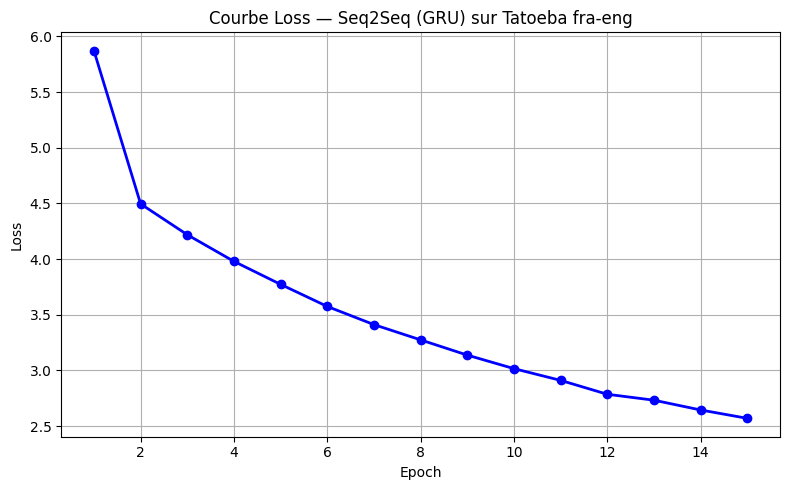

In [17]:
# ================================================================
# SEQ2SEQ — encodeur GRU + décodeur GRU + teacher forcing
# ================================================================
import matplotlib.pyplot as plt
class Encodeur(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.gru       = nn.GRU(embed_size, hidden_size, batch_first=True)

    def forward(self, x):
        return self.gru(self.embedding(x))


class Decodeur(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.gru       = nn.GRU(embed_size, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        out, hn = self.gru(self.embedding(x), hidden)
        return self.fc(out.squeeze(1)), hn


class Seq2Seq(nn.Module):
    def __init__(self, enc, dec, tgt_vocab_size):
        super().__init__()
        self.enc = enc; self.dec = dec
        self.tgt_vocab_size = tgt_vocab_size

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        B, T = tgt.shape
        outputs = torch.zeros(B, T, self.tgt_vocab_size).to(src.device)
        _, hidden = self.enc(src)
        dec_input = tgt[:, 0:1]
        for t in range(1, T):
            logits, hidden = self.dec(dec_input, hidden)
            outputs[:, t]  = logits
            use_tf    = torch.rand(1).item() < teacher_forcing_ratio
            dec_input = tgt[:, t:t+1] if use_tf else logits.argmax(dim=1, keepdim=True)
        return outputs


EMBED_SIZE = 64; HIDDEN_SIZE = 128
enc = Encodeur(len(vocab_src), EMBED_SIZE, HIDDEN_SIZE).to(device)
dec = Decodeur(len(vocab_tgt), EMBED_SIZE, HIDDEN_SIZE).to(device)
s2s = Seq2Seq(enc, dec, len(vocab_tgt)).to(device)
print(f'Encodeur : {sum(p.numel() for p in enc.parameters()):,} params')
print(f'Décodeur : {sum(p.numel() for p in dec.parameters()):,} params')

# Entraînement
opt_s2s  = optim.Adam(s2s.parameters(), lr=0.001)
crit_s2s = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
losses_s2s = []
for epoch in range(15):
    s2s.train()
    total = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt_s2s.zero_grad()
        out  = s2s(Xb, yb)
        loss = crit_s2s(out[:,1:].reshape(-1, len(vocab_tgt)), yb[:,1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(s2s.parameters(), 1.0)
        opt_s2s.step()
        total += loss.item()
    avg = total / len(train_loader)
    losses_s2s.append(avg)
    print(f'Epoch {epoch+1:2d} | Loss={avg:.4f}')

    

plt.figure(figsize=(8, 5))
plt.plot(range(1, 16), losses_s2s, marker='o', color='blue', linewidth=2)
plt.title("Courbe Loss — Seq2Seq (GRU) sur Tatoeba fra-eng")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

---
##  Étape III.6 — Décodage glouton + Beam search

In [11]:
# ================================================================
# DÉCODAGE GLOUTON
# ================================================================
def decoder_glouton(enc_m, dec_m, src_tensor, max_len=MAX_LEN):
    enc_m.eval(); dec_m.eval()
    with torch.no_grad():
        _, hidden = enc_m(src_tensor.unsqueeze(0).to(device))
        dec_input = torch.tensor([[BOS_IDX]], dtype=torch.long).to(device)
        generated = []
        for _ in range(max_len):
            logits, hidden = dec_m(dec_input, hidden)
            next_tok       = logits.argmax(dim=1).item()
            if next_tok == EOS_IDX: break
            generated.append(next_tok)
            dec_input = torch.tensor([[next_tok]], dtype=torch.long).to(device)
    return generated


# ================================================================
# BEAM SEARCH
# ================================================================
def beam_search(enc_m, dec_m, src_tensor, beam_width=3, max_len=MAX_LEN):
    enc_m.eval(); dec_m.eval()
    with torch.no_grad():
        _, hidden = enc_m(src_tensor.unsqueeze(0).to(device))
        beam      = [(0.0, [], hidden)]
        for _ in range(max_len):
            candidats = []
            for score, seq, hid in beam:
                last   = seq[-1] if seq else BOS_IDX
                last_t = torch.tensor([[last]], dtype=torch.long).to(device)
                logits, new_hid = dec_m(last_t, hid)
                log_p           = torch.log_softmax(logits, dim=1).squeeze(0)
                top_p, top_i    = torch.topk(log_p, beam_width)
                for i in range(beam_width):
                    tok = top_i[i].item()
                    if tok != EOS_IDX:
                        candidats.append((score+top_p[i].item(), seq+[tok], new_hid))
            if not candidats: break
            beam = sorted(candidats, key=lambda x: x[0], reverse=True)[:beam_width]
        return beam[0][1], beam[0][0]


print('=== Exemples de traduction ===')
for i in range(3):
    src = X_test[i]
    print(f'  Source    : {vocab_src.decoder(src.tolist())}')
    print(f'  Référence : {vocab_tgt.decoder(y_test[i].tolist())}')
    print(f'  Glouton   : {vocab_tgt.decoder(decoder_glouton(enc, dec, src))}')
    beam_out, sc = beam_search(enc, dec, src, beam_width=3)
    print(f'  Beam (k=3): {vocab_tgt.decoder(beam_out)} (score={sc:.4f})')
    print()

=== Exemples de traduction ===
  Source    : come outside.
  Référence : venez a l exterieur.
  Glouton   : viens le.
  Beam (k=3): viens ! ! ! ! ! ! ! ! ! ! ! ! ! (score=-37.5960)

  Source    : have fun.
  Référence : amusez vous bien !
  Glouton   : allez vous ! !
  Beam (k=3): allez vous ! ! ! ! ! ! ! ! ! ! ! ! (score=-33.0766)

  Source    : show tom in.
  Référence : faites entrer tom.
  Glouton   : fais le
  Beam (k=3): fais le ! ! ! ! ! ! ! ! ! ! ! ! (score=-41.1356)



---
##  Étape III.7 — Transformer (*Attention is all you need*)

Le Transformer remplace la récurrence par le **mécanisme d'attention**. Il n'a pas de gradient évanescent car tous les tokens interagissent directement.

In [12]:
# ================================================================
# POSITIONAL ENCODING
# Ajoute l'information de position car le Transformer n'a pas de récurrence
# ================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x : [B, T, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ================================================================
# TRANSFORMER POUR MODÈLE DE LANGAGE
# Architecture simple : embedding + positional encoding + couches transformer
# ================================================================
class TransformerLanguageModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, max_len=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)

        # Couche Transformer encoder
        encoder_layer  = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc          = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        # Masque causal : chaque position ne voit que les positions passées
        T    = x.size(1)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()

        # Padding mask
        pad_mask = (x == PAD_IDX)

        emb = self.pos_enc(self.embedding(x))
        out = self.transformer(emb, mask=mask, src_key_padding_mask=pad_mask)
        return self.fc(out)


model_transformer = TransformerLanguageModel(
    vocab_size=len(vocab_tgt), d_model=64, nhead=4,
    num_layers=2, dim_feedforward=128
).to(device)

print('Architecture Transformer :')
print(model_transformer)
print(f'\nParamètres : {sum(p.numel() for p in model_transformer.parameters()):,}')

Architecture Transformer :
TransformerLanguageModel(
  (embedding): Embedding(2623, 64, padding_idx=0)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=2623, bias=True)
)

Paramètres : 405,311


In [13]:
# ================================================================
# ENTRAÎNEMENT DU TRANSFORMER
# ================================================================
criterion_tr = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer_tr = optim.Adam(model_transformer.parameters(), lr=0.001)
losses_tr, ppls_tr = [], []

for epoch in range(15):
    model_transformer.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_tr.zero_grad()
        logits = model_transformer(X_batch)
        loss   = criterion_tr(logits.view(-1, len(vocab_tgt)), y_batch.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_transformer.parameters(), max_norm=1.0)
        optimizer_tr.step()
        total_loss += loss.item()
    avg = total_loss / len(train_loader)
    ppl = torch.exp(torch.tensor(avg)).item()
    losses_tr.append(avg); ppls_tr.append(ppl)
    print(f'Epoch {epoch+1:2d} | Loss={avg:.4f} | PPL={ppl:.2f}')

Epoch  1 | Loss=5.1738 | PPL=176.59
Epoch  2 | Loss=3.5037 | PPL=33.24
Epoch  3 | Loss=3.1659 | PPL=23.71
Epoch  4 | Loss=2.9550 | PPL=19.20
Epoch  5 | Loss=2.7769 | PPL=16.07
Epoch  6 | Loss=2.6376 | PPL=13.98
Epoch  7 | Loss=2.5129 | PPL=12.34
Epoch  8 | Loss=2.4033 | PPL=11.06
Epoch  9 | Loss=2.3005 | PPL=9.98
Epoch 10 | Loss=2.2053 | PPL=9.07
Epoch 11 | Loss=2.1171 | PPL=8.31
Epoch 12 | Loss=2.0337 | PPL=7.64
Epoch 13 | Loss=1.9562 | PPL=7.07
Epoch 14 | Loss=1.8802 | PPL=6.55
Epoch 15 | Loss=1.8253 | PPL=6.20


---
##  Étape III.8 — Évaluation : perplexité + BLEU

In [14]:
# ================================================================
# PERPLEXITÉ
# ================================================================
def calculer_perplexite(model, dataloader, device, vocab_size):
    model.eval()
    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    total = 0
    with torch.no_grad():
        for Xb, yb in dataloader:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = crit(model(Xb).view(-1, vocab_size), yb.view(-1))
            total += loss.item()
    avg = total / len(dataloader)
    return avg, torch.exp(torch.tensor(avg)).item()


_, ppl_lstm = calculer_perplexite(model_lm,          test_loader, device, len(vocab_tgt))
_, ppl_tr   = calculer_perplexite(model_transformer, test_loader, device, len(vocab_tgt))
print(f'Perplexité LSTM        : {ppl_lstm:.2f}')
print(f'Perplexité Transformer : {ppl_tr:.2f}')

Perplexité LSTM        : 2648.32
Perplexité Transformer : 16.07


In [15]:
# ================================================================
# SCORE BLEU
# ================================================================
try:
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
    import nltk; nltk.download('punkt', quiet=True)
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'nltk', '-q'])
    from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoother = SmoothingFunction().method1
refs, hyps_greedy, hyps_beam = [], [], []
n_eval = min(100, len(X_test))

for i in range(n_eval):
    src = X_test[i]
    refs.append([vocab_tgt.decoder(y_test[i].tolist()).split()])
    hyps_greedy.append(vocab_tgt.decoder(decoder_glouton(enc, dec, src)).split())
    hyps_beam.append(vocab_tgt.decoder(beam_search(enc, dec, src, 3)[0]).split())

bleu_g = corpus_bleu(refs, hyps_greedy, smoothing_function=smoother)
bleu_b = corpus_bleu(refs, hyps_beam,   smoothing_function=smoother)
print(f'BLEU — Glouton   : {bleu_g:.4f}')
print(f'BLEU — Beam (k=3): {bleu_b:.4f}')

BLEU — Glouton   : 0.0256
BLEU — Beam (k=3): 0.0131


---
##  Étape III.9 — Comparaison RNN / LSTM / GRU / Transformer


--- RNN ---
  PPL finale : 8.31

--- LSTM ---
  PPL finale : 10.20

--- GRU ---
  PPL finale : 7.71


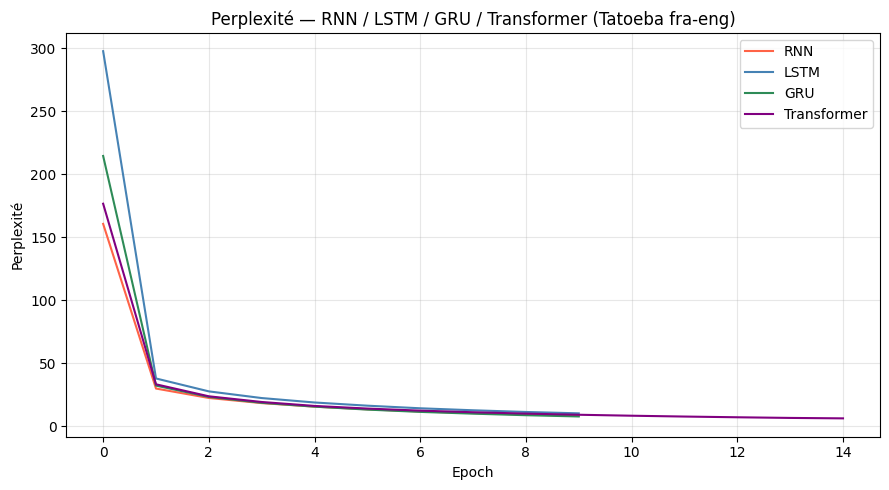


=== Tableau comparatif final ===
Modèle         PPL        Temps(s)     Paramètres     Stabilité
-----------------------------------------------------------------
RNN            8.31       44.38        531,071        Faible
LSTM           10.20      46.19        605,567        Élevée
GRU            7.71       60.79        580,735        Élevée
Transformer    6.20       0            405,311        Très élevée


In [16]:
# ================================================================
# COMPARAISON FINALE DES 4 ARCHITECTURES
# ================================================================
class ModelLangage(nn.Module):
    def __init__(self, arch_class, vocab_size, embed_size=64, hidden_size=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.rnn       = arch_class(embed_size, hidden_size, batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out)


resultats_arch = {}
architectures  = [('RNN', nn.RNN), ('LSTM', nn.LSTM), ('GRU', nn.GRU)]

for nom, arch_class in architectures:
    print(f'\n--- {nom} ---')
    m    = ModelLangage(arch_class, len(vocab_tgt)).to(device)
    opt  = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    ppls, t_total = [], 0
    for epoch in range(10):
        m.train()
        total = 0
        t0    = time.time()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(m(Xb).view(-1, len(vocab_tgt)), yb.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step(); total += loss.item()
        t_total += time.time() - t0
        avg = total / len(train_loader)
        ppls.append(torch.exp(torch.tensor(avg)).item())
    resultats_arch[nom] = {'ppls': ppls, 'ppl_final': ppls[-1],
                           'temps_s': round(t_total,2),
                           'params': sum(p.numel() for p in m.parameters())}
    print(f'  PPL finale : {ppls[-1]:.2f}')

# Ajouter le Transformer
resultats_arch['Transformer'] = {
    'ppls'     : ppls_tr,
    'ppl_final': ppls_tr[-1] if ppls_tr else 0,
    'temps_s'  : 0,
    'params'   : sum(p.numel() for p in model_transformer.parameters())
}

# Courbes
couleurs_arch = {'RNN': 'tomato', 'LSTM': 'steelblue', 'GRU': 'seagreen', 'Transformer': 'purple'}
plt.figure(figsize=(9, 5))
for nom, res in resultats_arch.items():
    plt.plot(res['ppls'], label=nom, color=couleurs_arch[nom])
plt.title('Perplexité — RNN / LSTM / GRU / Transformer (Tatoeba fra-eng)')
plt.xlabel('Epoch'); plt.ylabel('Perplexité')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Tableau comparatif
print('\n=== Tableau comparatif final ===')
stab = {'RNN': 'Faible', 'LSTM': 'Élevée', 'GRU': 'Élevée', 'Transformer': 'Très élevée'}
print(f'{"Modèle":<14} {"PPL":<10} {"Temps(s)":<12} {"Paramètres":<14} {"Stabilité"}')
print('-' * 65)
for nom, res in resultats_arch.items():
    print(f'{nom:<14} {res["ppl_final"]:<10.2f} {res["temps_s"]:<12} {res["params"]:<14,} {stab[nom]}')